<h1 style="color:#0000FF">Kurze Einführung in SymPy</h1>
<h3 style="color:#0000FF">Symbolische Mathematik mit Python</h3>

<h2 style="color:#FF0000">Lernziele</h2>

<font color="#FF0000">
<ul>
    <li>Die wichtigsten Befehle im Zusammenhang mit Variablen, Symbolen, Termen, Gleichungen, ... kennen und anwenden</li>
    <li>Höhere Mathematik mit SymPy (Differenzieren und Integrieren)</li>
    <li>Funktionen visualisieren</li>
</ul>
</font>

### Variablen und Terme

Um in Python symbolische Mathematik zu betreiben brauchen wir **Variabeln**. In **sympy** können Variabeln mit dem Befehl **symbols** erzeugt werden.

Wenn die symbolischen Variabeln definiert sind, können mit den verschiedenen Rechenoperationen / Funktionen mathemathische **Terme** gebildet werden!

In [1]:
# Symbolische Variablen definieren
from sympy import symbols
x = symbols('x')                # eine neue sym. Var.
y,z = symbols('y,z')            # mehrere sym. Var. definieren

# Mit symbolischen Variablen können math. Terme erzeugt werden!
term = x/(y**2+z**2)
print(term)

x/(y**2 + z**2)


In [2]:
# Vordefinierte symbolische Variablen
from sympy.abc import a, b
term = a+b
print(term)

a + b


In [3]:
# Variablen mit Indizes
k = symbols('k:4')
print(k)
print(k[0])
k_0, k_1, k_2, k_3 = k
print(k_1)

(k0, k1, k2, k3)
k0
k1


### Termumformungen

Die Umformung von **Termen** ist eine zentrale (und recht schwierige) Aufgabe in der Mathematik. In **sympy** gibt es viele verschiedene Befehle, welche sich mit Umformungen beschäftigen. Dabei ist der Befehl **simplify** das Universalwerkzeug um Terme zu vereinfachen. 

Mathematische Terme können sehr unterschiedlich aufgebaut sein und oft brauchen wir eine ganz bestimmte Termumformung (Faktorisieren, Ausmultiplizieren, ...) und daher gibt es neben dem **simplify**-Befehl noch viele weitere Befehle für diese spezifischen Umformungen:

* **factor** => Faktorisieren von Termen
* **expand** => Ausmultiplizieren von Termen
* **cancel** => Als einen gekürzten Bruch darstellen
* **apart**  => Partialbruchzerlegung
* usw.

In [4]:
import sympy as sym
term1 = sym.sin(x)**2+sym.cos(x)**2
print(term1)
term2 = sym.simplify(term1)
print(term2)

sin(x)**2 + cos(x)**2
1


In [5]:
bruch1 = (x**3-2*x**2+x)/(x**2-x)
print(bruch1)
bruch2 = sym.simplify(bruch1)
print(bruch2)

(x**3 - 2*x**2 + x)/(x**2 - x)
x - 1


In [6]:
# expand
prod1 = (x-1)**3*(x+2)**4
print(prod1)
prod2 = sym.expand(prod1)
print(prod2)

(x - 1)**3*(x + 2)**4
x**7 + 5*x**6 + 3*x**5 - 17*x**4 - 16*x**3 + 24*x**2 + 16*x - 16


In [7]:
# factor
prod3 = sym.factor(prod2)
print(prod3)

(x - 1)**3*(x + 2)**4


In [8]:
# apart
zaehler = sym.expand((x-1)**2*(x+3)**4)
nenner = sym.expand(x*(x+2)*(x-3)**3)
bruch = zaehler/nenner
print(bruch)
pbz = sym.apart(bruch)
print(pbz)

(x**6 + 10*x**5 + 31*x**4 + 12*x**3 - 81*x**2 - 54*x + 81)/(x**5 - 7*x**4 + 9*x**3 + 27*x**2 - 54*x)
x + 17 + 9/(250*(x + 2)) + 17808/(125*(x - 3)) + 9792/(25*(x - 3)**2) + 1728/(5*(x - 3)**3) - 3/(2*x)


In [9]:
# cancel
bruch_neu = sym.cancel(pbz)
print(bruch_neu)

(x**6 + 10*x**5 + 31*x**4 + 12*x**3 - 81*x**2 - 54*x + 81)/(x**5 - 7*x**4 + 9*x**3 + 27*x**2 - 54*x)


In [10]:
# trigsimp
term = 2*sym.sin(x)*sym.cos(x)
print(term)
term_neu = sym.trigsimp(term)
print(term_neu)

2*sin(x)*cos(x)
sin(2*x)


In [11]:
# expand_trig
term_expand = sym.expand_trig(term_neu)
print(term_expand)

2*sin(x)*cos(x)


In [12]:
# Weitere Befehle:

# powsimp
# expand_power_exp
# expand_power_base
# expand_log
# logcombine
# ...

### Gleichungen, Gleichungssysteme und Ungleichungen

Mit dem Befehl **solve** können Gleichungen, Gleichungssysteme und auch Ungleichungen gelöst werden.

Dabei gibt es zwei Möglichkeiten eine Gleichung zu definieren:

* Einerseits können Gleichungen immer auf Null gesetzt werden und dann sind die Lösungen der Gleichung die Nullstellen des Terms auf der einen Seite des Gleichheitszeichens. Sei die Gleichung in der Form $$T\left(x\right) = 0$$ gegeben, so kann die Lösung wie folgt berechnet werden: lsg = solve(T(x),x)


* Die etwas aufwendigere (aber weitaus vielseitigere) Variante besteht darin, dass in **sympy** ein Gleichungsobjekt für die Gleichung erstellt wird. Dies erfolgt mit dem Befehl **Eq** (bzw. **Lt**, **Gt**, **Le**, **Ge** für Ungleichungen): gl = Eq(links(x),rechts(x)). 

Ein Gleichungssystem wird als eine Liste(eckige Klammern) von Gleichungsobjekten definiert.

In [13]:
R1,R2,R_par = sym.symbols('R1,R2,R_par')
formel = sym.Eq(R_par,1/(1/R1+1/R2))
R_2=sym.solve(formel,R2)
print(R_2)

[R1*R_par/(R1 - R_par)]


In [14]:
gl1 = 1/(x-1)+1/(x+1)-1
print(gl1)
lsg1 = sym.solve(gl1)
print(lsg1)

-1 + 1/(x + 1) + 1/(x - 1)
[1 - sqrt(2), 1 + sqrt(2)]


In [15]:
gl2 = sym.Eq(1/(x-1)+1/(x+1),1)
print(gl2)
lsg2 = sym.solve(gl2,x)
print(lsg2)

Eq(1/(x + 1) + 1/(x - 1), 1)
[1 - sqrt(2), 1 + sqrt(2)]


In [16]:
gl_sys = [sym.Eq(2*x+y,4),sym.Eq(x-3*y,-5)]
print(gl_sys)
lsg_sys = sym.solve(gl_sys)
print(lsg_sys)

[Eq(2*x + y, 4), Eq(x - 3*y, -5)]
{x: 1, y: 2}


In [17]:
ungl = sym.Lt(1/(x+1),1)
print(ungl)
lsg_ungl = sym.solve(ungl)
print(lsg_ungl)

1/(x + 1) < 1
(0 < x) | (x < -1)


### Funktionen und ihre grafische Darstellung

Funktionen können in **sympy** als Terme (mit einer oder mehreren unabhängigen Variablen) definiert werden (Scheinfunktion). 

**Bemerkung**: Natürlich können wir in Python auch "richtige" Funktionen definieren. Mit diesen Funktionen können wir dann zwar korrekt Funktionswerte berechnen aber im mathematischen Kontext (Verschachtelung von Funktionen, Ableitungen von Funktionen, ...) sind diese (Python-)Funktionen nicht brauchbar!

Um Funktionswerte einer solchen (Schein-)Funktion zu berechnen gibt es den Befehl **subs**.

Funktionsgraphen können mit den Befehlen der Unterbibliothek **sympy.plotting** erzeugt werden:

* **plot** => Graph einer reellwertigen Funktion mit einer Unabhängigen in kartesischen Koordinaten

* **plot3d** => Graph einer reellwertigen Funktion mit zwei Unabhängigen in kartesischen Koordinaten

* **plot_parametric** => Graph eine parametrisierten Kurve

* usw.

Die Befehle der **matplotlib** Bibliothek sind deutlich mächtiger als die Befehle der **sympy.plotting** Bibliothek. Daher ist es oft sinnvoll eine Wertetabelle zu einer Funktion zu erzeugen und mit den Befehlen aus der Bibliothek **matplotlib** die Grafiken zu zeichnen! 

7


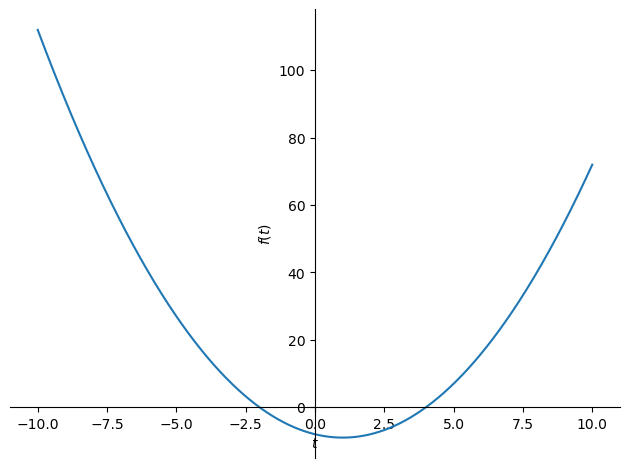

In [18]:
from sympy.plotting import plot, plot_parametric, plot3d
t = sym.symbols('t')
f_t = t**2-2*t-8
f_5 = f_t.subs({t:5})
print(f_5)
plot(f_t)

[-2, 4]


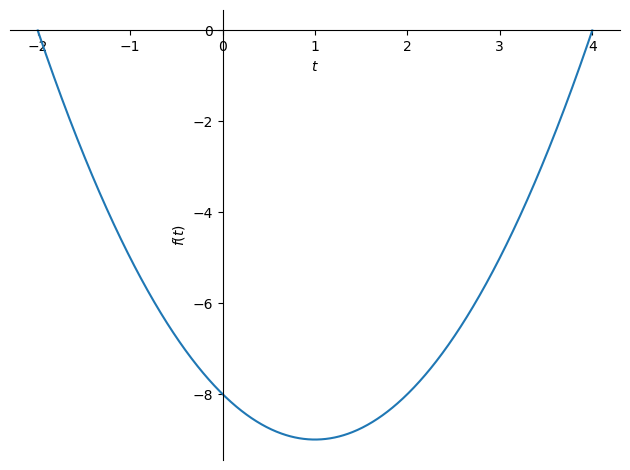

In [19]:
null = sym.solve(f_t)
print(null)
plot(f_t,(t,min(null),max(null)))

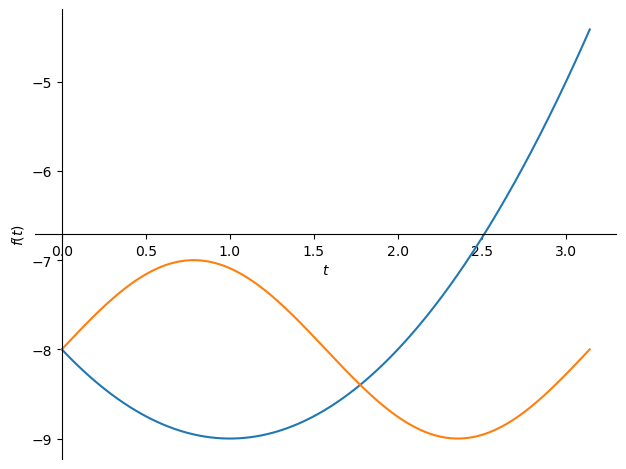

In [20]:
g_t = sym.sin(2*t)-8
plot(f_t,g_t,(t,0,sym.pi))

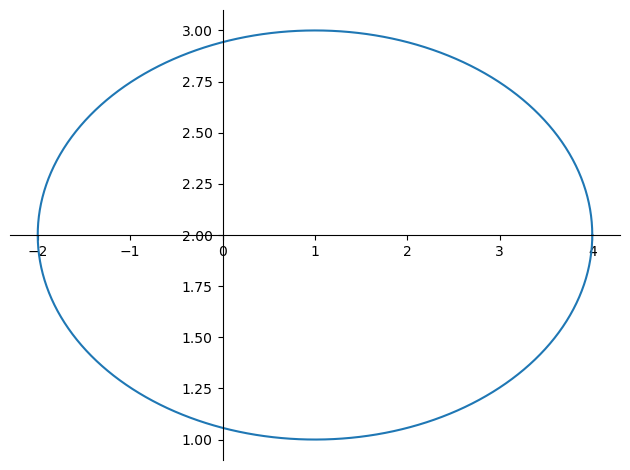

In [21]:
x_t = 1+3*sym.cos(t)
y_t = 2+sym.sin(t)
plot_parametric(x_t,y_t,(t,0,2*sym.pi))

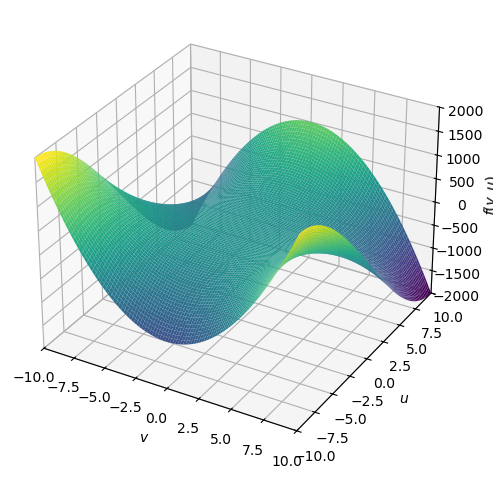

In [22]:
u,v = sym.symbols('u v')
w_uv = u**3-3*u*v**2
plot3d(w_uv)

In [23]:
# Wertetabelle und Verwendung von matplotlib
import numpy as np

xx = np.arange(-5,5.1,0.1)
#print(xx)

In [24]:
f_x = sym.exp(-x**2)
yy = [f_x.evalf(subs={x:xk}) for xk in xx]
#print(yy)

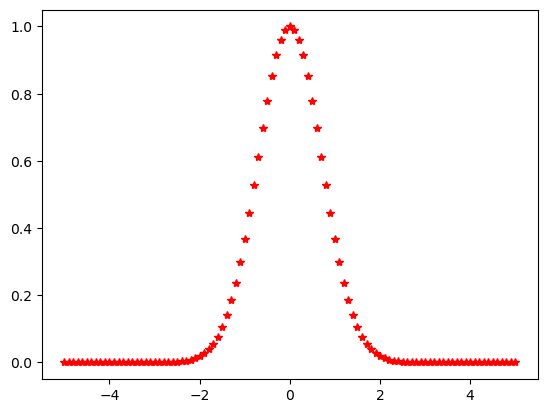

In [25]:
import matplotlib.pyplot as plt
plt.plot(xx,yy,'r*')
plt.show()

### Höhere Mathematik

Für die höhere Mathematik kennt **sympy** natürlich ebenfalls entsprechende Werkzeuge. Hier einige wichtige Befehle:

* **limit** => Grenzwert einer Folge / Funktion

* **diff** => Ableitung von Funktionen

* **integrate** => Bestimmtes und unbestimmtes Integral einer Funktion

* **series** => Entwicklung einer Funktion in eine Taylorreihe

* usw.

In [26]:
# Grenzwerte
from sympy import oo, limit
n = sym.symbols('n')
f_n = n/(n+1)
lim = limit(f_n,n,oo)
print(lim)

1


In [27]:
# Ableitungen
fx = x/(x+1)
print(fx)
d_fx_dx = sym.diff(fx,x)
print(d_fx_dx)
d2_fx_dx2 = sym.diff(fx,x,2)
print(d2_fx_dx2)

x/(x + 1)
-x/(x + 1)**2 + 1/(x + 1)
2*(x/(x + 1) - 1)/(x + 1)**2


In [28]:
# Integrieren
fx = x/(x+1)
print(fx)
Fx = sym.integrate(fx,x)
print(Fx)
A = sym.integrate(fx,(x,0,1))
print(A)

x/(x + 1)
x - log(x + 1)
1 - log(2)


In [29]:
# Taylorreihen
fx = x/(x+1)
print(fx)
taylor_fx = fx.series(x,0,10)
print(taylor_fx)

x/(x + 1)
x - x**2 + x**3 - x**4 + x**5 - x**6 + x**7 - x**8 + x**9 + O(x**10)


x**9 - x**8 + x**7 - x**6 + x**5 - x**4 + x**3 - x**2 + x


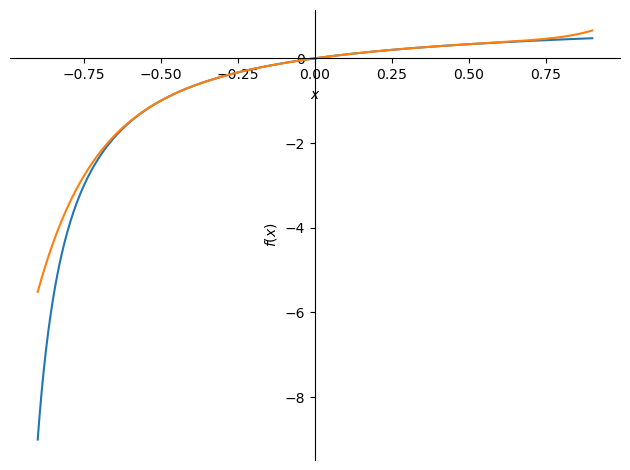

In [30]:
taylor_fx = fx.series(x,0,10).removeO()
print(taylor_fx)
plot(fx,taylor_fx,(x,-0.9,0.9))

### Übungsaufgabe

In einem Thaleskreis sei ein rechtwinkliges Dreieck mit dem Winkel $\alpha$ gegeben. Über den beiden Katheten werden jeweils die grössten Kreise (zwischen Thaleskreis und Katheten) einbeschrieben (Radien $x_1$ und $x_2$). 

Für welchen Winkel $\alpha$ ist die Summe der Flächen der beiden Kreise maximal bzw. minimal?

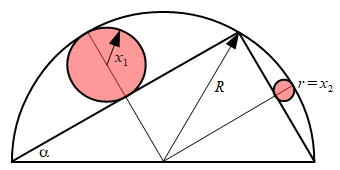

In [31]:
from IPython.display import Image
Image("b1_kap7.jpg")

**Lösung**

Die Katheten des rechtwinkligen Dreiecks sind jeweils Tangenten an die einbeschriebenen Kreise. Daher stehen die Geraden durch den Mittelpunkt des Thaleskreises durch die Mittelpunkte der einbeschriebenen Kreise rechtwinklig zu den Katheten und es ergeben sich zwei neue (kongruente) rechtwinklige Dreiecke:

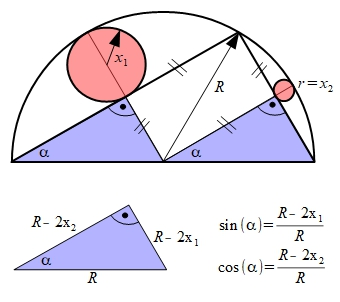

In [32]:
Image("b2_kap7.jpg")

Mit diesem rechtwinkligen Dreieck lassen sich Gleichungen für die Bestimmung der Radien $x_1$ und $x_2$ aufstellen:

$$\sin\left(\alpha\right)=\frac{R-2\cdot x_1}{R}$$

$$\cos\left(\alpha\right)=\frac{R-2\cdot x_2}{R}$$

Diese Gleichungen definieren wir in Python:

In [33]:
# Symbolische Variabeln definieren:
a = sym.symbols('a')          # Für den Winkel alpha
x1, x2 = sym.symbols('x1 x2') # Radien der einbeschriebenen Kreise
R = sym.symbols('R')          # Radius Thaleskreis (Parameter)

In [34]:
# Gleichungen für die Radien der beiden Kreise:
gl_links = sym.Eq(sym.sin(a),(R-2*x1)/R)
gl_rechts = sym.Eq(sym.cos(a),(R-2*x2)/R)
print(gl_links)
print(gl_rechts)

Eq(sin(a), (R - 2*x1)/R)
Eq(cos(a), (R - 2*x2)/R)


In [35]:
# Gleichungen nach den gesuchten Radien auflösen:
lsg_x1 = sym.solve(gl_links,x1)
lsg_x2 = sym.solve(gl_rechts,x2)
print('x_1 = ',lsg_x1)
print('x_2 = ',lsg_x2)

x_1 =  [R*(1 - sin(a))/2]
x_2 =  [R*(1 - cos(a))/2]


Die Radien der einbeschriebenen Kreise ergeben sich zu (in Abhängigkeit des Winkels $\alpha$):

$$ x_1\left(\alpha\right)=\frac{R}{2}\left(1-\sin\left(\alpha\right)\right)$$

$$x_2\left(\alpha\right)=\frac{R}{2}\left(1-\cos\left(\alpha\right)\right)$$

Nun kann die Summe der Kreisflächen berechnet werden:

In [36]:
# Kreisflächen 
#
# ACHTUNG: Die Lösungen der beiden Gleichungen sind Listen (mit einem
# Element) und es muss mit einem Index (0) auf die gefundenen Radien 
# zugreifen werden!)
A_links = sym.pi*lsg_x1[0]**2
A_rechts = sym.pi*lsg_x2[0]**2
A_ges = A_links+A_rechts
print('A_links = ',A_links)
print('A_rechts = ',A_rechts)
print()
print('A_ges = ',A_ges,' = ',sym.simplify(A_ges))

A_links =  pi*R**2*(1 - sin(a))**2/4
A_rechts =  pi*R**2*(1 - cos(a))**2/4

A_ges =  pi*R**2*(1 - sin(a))**2/4 + pi*R**2*(1 - cos(a))**2/4  =  pi*R**2*(-2*sqrt(2)*sin(a + pi/4) + 3)/4


Für die Summe der beiden Kreisflächen findet man somit:

$$A_{ges}\left(\alpha\right) = \frac{R^2\pi}{4}\left(3-2\sqrt{2}\sin\left(\alpha+\frac{\pi}{4}\right)\right)$$

Die Fläche ist eine Funktion in Abhängigkeit des Winkels $\alpha$. Um eine bessere Vorstellung zu erhalten, können wir die Funktion visualisieren (z.B. mit $R=1$, für den Winkelbereich $0^{\circ}\leq\alpha\leq 90^{\circ}$):

pi*(1 - sin(a))**2/4 + pi*(1 - cos(a))**2/4


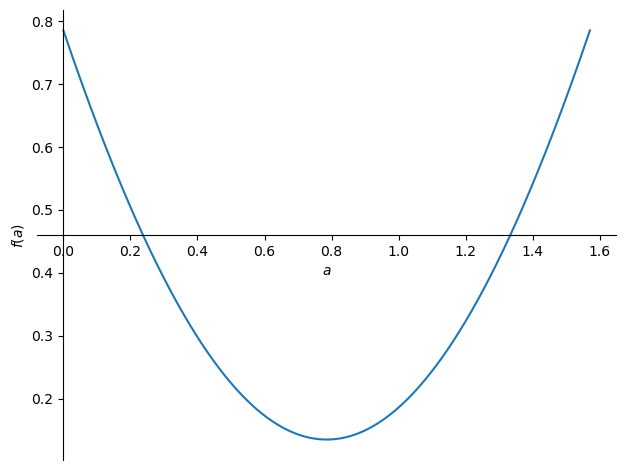

In [37]:
# Skizze der Abhängigkeit für R=1
A_ges_R_1 = A_ges.subs({R:1})    # R = 1 einsetzen 
print(A_ges_R_1)
plot(A_ges_R_1,(a,0,sym.pi/2))

Aus der Grafik ist ersichtlich, dass sich für $\alpha_1 = 0^{\circ}$ und für $\alpha_2 = 90^{\circ}$ jeweils maximale Fläche ergibt (Grenzfälle => das rechtwinklige Dreieck im Thaleskreis entartet zu einer Linie (Diagonale des Thaleskreises) => die beiden einbeschriebenen Kreise haben dann die Radien $0$ und $\frac{R}{2}$)!

Für das gesuchte Flächenminimum lösen wir die Extremwertaufgabe:

In [38]:
# Extremwertaufgabe lösen:
dA_da = sym.diff(A_ges,a)   # Flächenfunktion nach dem Winkel ableiten
print('dA/da = ',dA_da,' = ',sym.simplify(dA_da))

dA/da =  -pi*R**2*(1 - sin(a))*cos(a)/2 + pi*R**2*(1 - cos(a))*sin(a)/2  =  -sqrt(2)*pi*R**2*cos(a + pi/4)/2


Für die Ableitung finden wir:

$$\frac{d}{d\alpha}A_{ges}\left(\alpha\right) = -\frac{\sqrt{2}\pi R^2}{2}\cos\left(\alpha+\frac{\pi}{4}\right)$$

Die Nullstellen dieser Ableitung sind die Kandidaten für die Extremstellen:

In [39]:
# Nullstellen der Ableitung bestimmen:
lsg_a = sym.solve(dA_da,a)
print(lsg_a)

[-3*pi/4, pi/4]


Python liefert zwei Nullstellen! Für die gegebene Aufgabe kömmen nur Winkel im Bereich $0^{\circ}\leq \alpha \leq 90^{\circ}$ in Frage. Somit ist der Winkel $\alpha_3 = 45^{\circ}$ der einzige Kandidat für die Extremstelle. Aus der obigen Grafik der Flächenfunktion sehen wir, dass dort die Fläche ein Minimum annimmt!

Für $\alpha_3=45^{\circ}$ ergibt sich also eine minimale Flächensumme!